# Import

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm  
from data_fitting.module_fitzcu import *
from data_fitting.abcd_rf_fit import *
from singleshotplot import hist as histplot
from qick import *
from qick.asm_v2 import AveragerProgramV2
from qick.asm_v2 import QickSpan, QickSweep1D
from qick.asm_v2 import AsmV2
import json
import datetime
import pprint as pp
from yamltool import yml_comment

In [3]:
import Pyro4
from qick import QickConfig
Pyro4.config.SERIALIZER = "pickle"
Pyro4.config.PICKLE_PROTOCOL_VERSION=4

ns_host = "192.168.10.35"
# ns_host = "localhost"
ns_port = 8886
proxy_name = "myqick"

ns = Pyro4.locateNS(host=ns_host, port=ns_port)
soc = Pyro4.Proxy(ns.lookup(proxy_name))
soccfg = QickConfig(soc.get_cfg())
print(soccfg)

QICK running on ZCU216, software version 0.2.342

Firmware configuration (built Tue Sep 10 16:13:40 2024):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 0, DAC tile 1, DAC tile 3], [DAC tile 2], [ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - envelope memory 16384 samples (1.709 us)
		fs=9584.640 Msps, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 0 is 0_230, on JHC3
	1:	axis_signal_gen_v6 - envelope memory 4096 samples (0.427 us)
		fs=9584.640 Msps, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 1 is 1_230, on JHC4
	2:	axis_signal_gen_v6 - envelope memory 8192 samples (0.855 us)
		fs=9584.640 Msps, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 2 is 2_230, on JHC3
	3:	axis_signal_gen_v6 - envelope memory 4096 samples (0.427 us)
		fs=9584.640 Msps, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2,

In [1]:
from os.path import isdir, join
import os
import requests
# from datetime import datetime
import datetime
from numpy import pi
import re
import Labber

def hdf5_generator(
        filepath: str,
        x_info:dict, z_info:dict, 
        y_info:dict = None, comment = None, tag = None):
    np.float=float
    np.bool=bool
    zdata = z_info['values']
    z_info.update({'complex': True, 'vector': False})
    log_channels = [z_info]
    step_channels = list(filter(None, [x_info, y_info]))

    fObj = Labber.createLogFile_ForData(filepath, log_channels, step_channels)
    if y_info:
        for trace in zdata:
            fObj.addEntry({z_info['name']: trace})
    else:
        fObj.addEntry({z_info['name']: zdata})

    if comment: fObj.setComment(comment)
    if tag: fObj.setTags(tag)
    


def get_next_filename_labber(dest_path: str, exp_name: str, yoko:str=None) -> str:
    # make sure dest_path is absolute path
    dest_path = os.path.abspath(dest_path)
    yy, mm, dd = datetime.datetime.today().strftime('%Y-%m-%d').split('-')
    save_path = os.path.join(dest_path, yy, mm, f"Data_{mm}{dd}")
    os.makedirs(save_path, exist_ok=True)

    existing_files = [f for f in os.listdir(save_path) if re.match(
        rf"{re.escape(exp_name)}_\d+\.hdf5", f)]
    next_index = max([int(re.search(r"_(\d+)", f).group(1))
                     for f in existing_files], default=0) + 1
    if yoko is not None:
        return os.path.join(save_path, f"{exp_name}_{yoko:.2f}mA")
    else:
        return os.path.join(save_path, f"{exp_name}_{next_index}")

data_path = r'C:\Users\QEL\Desktop\2D3QFF1'

In [4]:
Yoko_current=None

# System config

In [5]:
r1 = 5350
r2 = 6058
r3 = 7447
r4 = 5795.62
r5 = 5917.51
r6 = 6051.89

r = [r1, r2, r3, r4, r5, r6]

In [6]:
q1, q2, q3, q4, q5, q6 = [2, 4, 2, 11, 9, 3]
q = [q1, q2, q3, q4, q5, q6]

In [7]:
qubit_idx = 2
config = {
    ## Channel Params. ##
    'res_ch': 0,
    'ro_ch': 0,
    'qubit_ch': q[qubit_idx],

    ## Res Pulse Params. ##
    'f_res': r[qubit_idx], # [MHz]
    'res_len': 5, # [us]
    'res_phase': 0, # [deg]
    'res_gain': 0.5, # [DAC units]
    'res_sigma':0.004,
    ## Readout Params. ##
    'trig_time': 0.49, # [us]
    'ro_len': 5, # [us]
    'relax_delay': 50, # [us]
    'thresholds': None,

    ## Qubit Params. ##
    'qb_pulse_style': 'arb',
    'f_ge': 348.22, # [MHz]
    'nqz':2,
    'qubit_gain': 1,
    'probe_len': 5, # [us]
    'flat_top_len':2, # [us]
    "pi_gain":  0.001, # [DAC units]
    "pi2_gain": 0.001, # [DAC units]
    'qubit_phase': 0,
    'sigma': 0.1/5,
    'ramsey_freq': 3, # [MHz]
     }

# Resonator Spectroscopy

In [8]:
## Using the Dynamically Configured Readout Channel ##
class SingleToneSpectroscopyProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        loopbefore  = AsmV2()
        loopbefore.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.add_loop("freqloop", cfg["steps"], exec_before=loopbefore)
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        
        self.add_gauss(ch=res_ch, name="res_ramp",sigma=cfg['res_sigma'], length=5*cfg['res_sigma'])
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="res_ramp",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )

    def _body(self, cfg):
        # self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])


In [9]:
qubit_idx = 2
center = r[qubit_idx]

START_FREQ = center - 10 # [MHz]
STOP_FREQ =  center + 10 # [MHz]

# START_FREQ = 7000 # [MHz]
# STOP_FREQ =  7600 # [MHz]
STEPS = 201

exp_cfg = {
    'steps': STEPS, # Number of sweep points
    'f_res': QickSweep1D('freqloop', START_FREQ, STOP_FREQ), # [MHz]
    'res_gain': 0.7
}
run_cfg = {**config, **exp_cfg}


  0%|          | 0/10 [00:00<?, ?it/s]

c:\Users\QEL\Desktop\tprocv2_guidemo-2DQ12\csutscrip\data_fitting\abcd_rf_fit\abcd_rf_fit.py:187: UserWarning: Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False
  warnings.warn("Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False", UserWarning)


{'Fres(GHz)': 7447067100.114,
 'Qi': 36699,
 'Ql': 3674,
 'absQc': 4083,
 'κ(MHz)': 2.03}


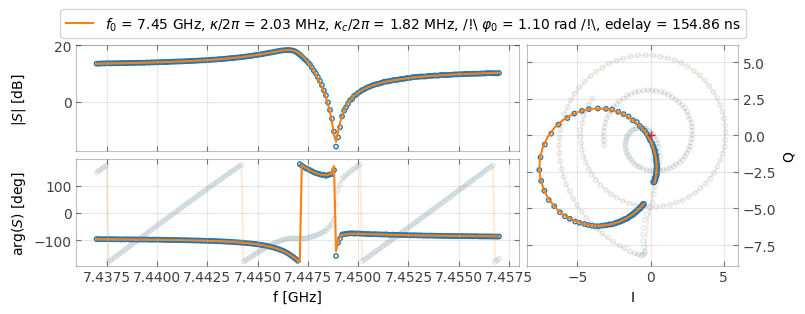

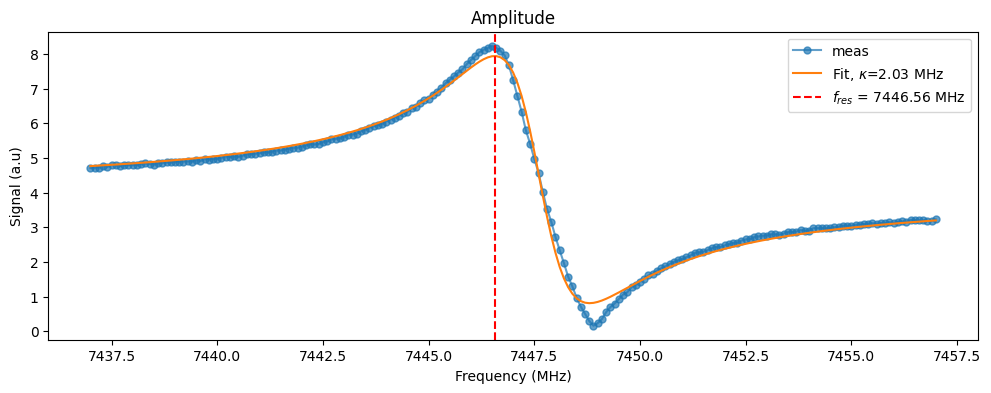

In [10]:
pyavg = 10

prog = SingleToneSpectroscopyProgram(soccfg, reps=100, final_delay=1, cfg=run_cfg)
iq_list = prog.acquire(soc, rounds=pyavg, progress=True)
freqs = prog.get_pulse_param("res_pulse", "freq", as_array=True)
res_onetone = (iq_list[0][0].dot([1,1j]))

fit = resonator_circlefit(freqs, res_onetone, solve_type='hm')
f = resonator_analyze(freqs, res_onetone)
f_res = round(fit[0]/1e6, 3)
config['f_res'] = f_res

In [28]:
data_path = data_path
exp_name = f"R{qubit_idx+1} resonator spec"


file_path = get_next_filename_labber(data_path, exp_name, Yoko_current)
hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Frequency', 'unit': "Hz",
                'values': freqs*1e6},  

        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  res_onetone},
        comment=(f'f_res = {f_res:.3f} MHz\
                 \nYoko = {Yoko_current} mA'),
        tag= 'OneTone'
)

# Qubit Spec

In [11]:
class PulseProbeSpectroscopyProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']

        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop("freqloop", cfg["steps"])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_gauss(ch=res_ch, name="res_ramp",sigma=cfg['res_sigma'], length=5*cfg['res_sigma'], even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="res_ramp",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        self.add_gauss(ch=qubit_ch, name="qubit_ramp",sigma=cfg['res_sigma'], length=5*cfg['res_sigma'], even_length=True)
        self.add_pulse(ch=qubit_ch, name="qubit_pulse",
                       style="flat_top", 
                       envelope="qubit_ramp",
                       length=cfg['probe_len'], 
                       freq=cfg['f_ge'], 
                       phase= 0,
                       gain=cfg['qubit_gain'],
                      )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse", t=0)
        self.delay_auto(t=0.05, tag='wait')
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [66]:
cemter = 5950
SPAN = 100
START_FREQ = cemter - SPAN # [MHz]
STOP_FREQ = cemter + SPAN  # [MHz]

STEPS = 101

config.update({'qmixer_freq':cemter, 'qubit_gain':1, 'qubit_ch':0, 'nqz':2})
expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'probe_len':5,
    ## Qubit Params. ##
    'f_ge': QickSweep1D('freqloop', START_FREQ, STOP_FREQ), # [MHz]
     }

run_cfg = {**config, **expt_cfg}

  0%|          | 0/50 [00:00<?, ?it/s]

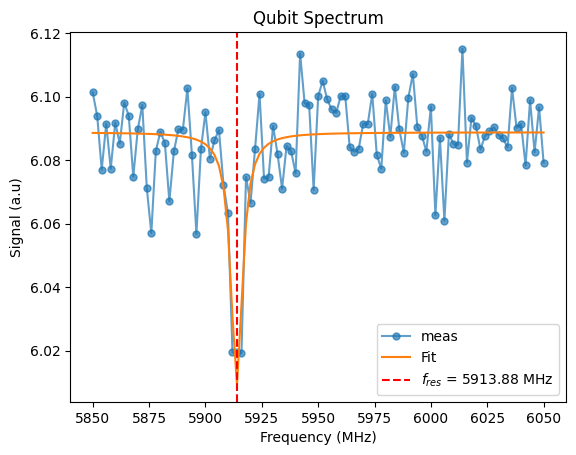

In [67]:
pyavg = 50
qspec=PulseProbeSpectroscopyProgram(soccfg, reps=100, final_delay=1, cfg=run_cfg)
iq_list = qspec.acquire(soc, rounds=pyavg, progress=True)
freqs = qspec.get_pulse_param('qubit_pulse', "freq", as_array=True)

f_q = spectrum_analyze(freqs, (iq_list[0][0].dot([1,1j])))
config['f_ge'] = round(f_q, 3)
config['qmixer_freq']= round(f_q,3)

In [746]:
data_path = data_path
exp_name = f"q{qubit_idx} qubit spec"
try:
        run_cfg.pop('f_ge')
except:
        pass
dict_val = yml_comment(run_cfg)

file_path = get_next_filename_labber(data_path, exp_name, Yoko_current)
hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Frequency', 'unit': "Hz",
                'values': freqs*1e3},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  iq_list[0][0].dot([1,1j])},
        comment=(f'f_q = {f_q} MHz\
                 \nYoko = {Yoko_current} mA\
                 \n{run_cfg["res_gain"]}, qb_gain={run_cfg["qubit_gain"]}\
                 \n\n{dict_val}'),
        tag='TwoTone')

# Length Rabi

In [ ]:
class LengthRabiProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        # self.add_loop("lenloop", cfg["steps"])
        self.add_gauss(ch=res_ch, name="res_ramp",sigma=cfg['res_sigma'], length=5*cfg['res_sigma'], even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="res_ramp",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )

        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'], 
                        phase= cfg['qubit_phase'],
                        gain=cfg['qubit_gain'],
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                           style="flat_top", 
                           envelope="ramp", 
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['qubit_gain'],
                           length = cfg['flat_top_len']
                          )
        
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse", t=0)  #play probe pulse

        self.delay_auto(t=0.0, tag='waiting')
        
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [ ]:
START_LEN = 0.01 # [DAC units]
STOP_LEN = 3 # [DAC units]
STEPS = 50

config.update({'relax_delay':50, 'qb_pulse_style':'flat_top', 'sigma':0.1, 'flat_top_len':0.1, 'nqz':2})
expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'qmixer_freq':config['f_ge'],
    'qubit_gain': 0.8
     }
run_cfg = {**config, **expt_cfg}

length = np.linspace(START_LEN, STOP_LEN, STEPS)
length_rabi=[]
for i in tqdm(length):
    run_cfg['flat_top_len'] = i
    prog = LengthRabiProgram(soccfg,reps=100,final_delay=run_cfg['relax_delay'], cfg=run_cfg)
    iq_list = prog.acquire(soc, rounds=50, progress=False)
    # t = prog.get_pulse_param('qubit_pulse', "length", as_array=True)
    length_rabi.append(iq_list[0][0].dot([1,1j]))
length_rabi = np.array(length_rabi)
lengthrabi_analyze(length, length_rabi)

In [ ]:
data_path = data_path
exp_name = f"q{qubit_idx+1} length rabi"


file_path = get_next_filename_labber(data_path, exp_name)
hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Time', 'unit': "s",
                'values': length*1e-6},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values': np.array(amp)},
        comment=f'relax = {run_cfg["relax_delay"]} us, \n{run_cfg}',
        tag='Rabi')

# Power Rabi

In [68]:
class AmplitudeRabiProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_loop("gainloop", cfg["steps"])

        self.add_gauss(ch=res_ch, name="res_ramp",sigma=cfg['res_sigma'], length=5*cfg['res_sigma'], even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="res_ramp",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'], 
                        phase= cfg['qubit_phase'],
                        gain=cfg['qubit_gain'],
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                           style="flat_top", 
                           envelope="ramp", 
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['qubit_gain'],
                           length = cfg['flat_top_len']
                          )
        
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        if self.cfg['rabi_protocal'] == 'pi':
            self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse", t=0)  #play probe pulse
        elif self.cfg['rabi_protocal'] == 'pipi':
            self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse", t=0)  
            self.delay_auto(0.0)
            self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse", t=0)
            self.delay_auto(0.0)

        self.delay_auto(t=0.05, tag='waiting')
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t = 0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [73]:
START_GAIN = 0 # [DAC units]
STOP_GAIN = 1 # [DAC units]
STEPS = 100


config.update({'relax_delay':50, 'qb_pulse_style':'arb', 'sigma':0.2, 'flat_top_len':0.1, 'nqz':2, 'qubit_ch':0})
expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'qmixer_freq':config['f_ge'],
    "qubit_gain": QickSweep1D('gainloop', START_GAIN, STOP_GAIN), # [DAC units]
    'rabi_protocal': 'pi',
     }
run_cfg = {**config, **expt_cfg}

  0%|          | 0/50 [00:00<?, ?it/s]

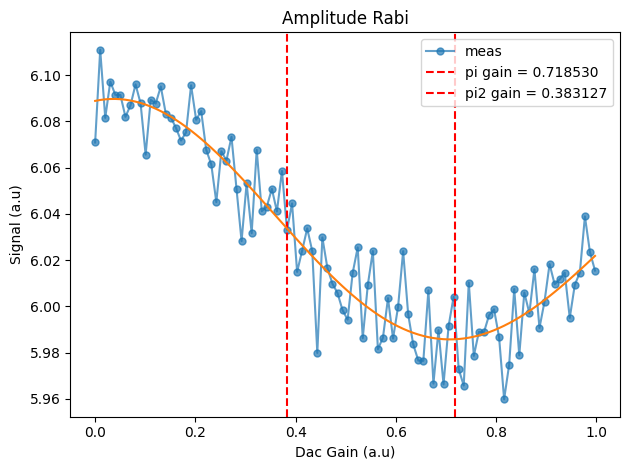

In [74]:
pyavg = 50
run_cfg['rabi_protocal']='pi'
amp_rabi=AmplitudeRabiProgram(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = amp_rabi.acquire(soc, rounds=pyavg, progress=True, threshold=run_cfg['thresholds'])
gains = amp_rabi.get_pulse_param('qubit_pulse', "gain", as_array=True)
power_rabi = iq_list[0][0].dot([1,1j])
config['pi_gain'], config['pi2_gain'] = amprabi_analyze(gains, (iq_list[0][0].dot([1,1j])), protocal=None)

In [579]:
data_path = data_path
exp_name = f"q{qubit_idx+1} power rabi ef"


file_path = get_next_filename_labber(data_path, exp_name, Yoko_current)
hdf5_generator(
        filepath=file_path,
        x_info={'name': 'DAC Gain', 'unit': "a.u",
                'values': gains},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  iq_list[0][0].dot([1,1j])},
        comment=f'relax={run_cfg["relax_delay"]}, at {Yoko_current}mA\
                \n\n{run_cfg}',
        tag='Rabi')

# Drag

In [ ]:
class DragProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured   
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)


        # self.add_loop("dragloop", cfg["steps"])
        
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const", 
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        # self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        self.add_DRAG(ch=qubit_ch, name="drag", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True,
                      alpha=cfg['alpha'], delta=cfg['delta']
                      )
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="x180", 
                        style="arb", 
                        envelope="drag", 
                        freq=cfg['f_ge'],
                        phase=0,
                        gain=cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="y90", 
                        style="arb", 
                        envelope="drag", 
                        freq=cfg['f_ge'],
                        phase=90,
                        gain=-cfg['pi2_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="y180", 
                        style="arb", 
                        envelope="drag", 
                        freq=cfg['f_ge'],
                        phase=90,
                        gain=cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="x90", 
                        style="arb", 
                        envelope="drag", 
                        freq=cfg['f_ge'],
                        phase=0,
                        gain=-cfg['pi2_gain'], 
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                           style="flat_top", 
                           envelope="drag", 
                           length = cfg['flat_top_len'],
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['pi_gain'],
                          )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        if self.cfg['case']==1:
            self.pulse(ch=self.cfg["qubit_ch"], name="x180", t=0)  
            self.delay_auto(0.01)
            self.pulse(ch=self.cfg["qubit_ch"], name="y90", t=0)
        elif self.cfg['case']==2:
            self.pulse(ch=self.cfg["qubit_ch"], name="y90", t=0)  
            self.delay_auto(0.01)
            self.pulse(ch=self.cfg["qubit_ch"], name="x180", t=0)
            
        self.delay_auto(0.01, tag='wait') # wait_time after last pulse

        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) # play probe pulse
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

START_alpha= 0 # [us]
STOP_alpha = 0.01 # [us]
STEPS = 30

expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'delta': 0.3,
    'case':1

    }

run_cfg = {**config, **expt_cfg}

In [271]:
class DragProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)


        # self.add_loop("dragloop", cfg["steps"])
        
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const", 
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        # self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        self.add_DRAG(ch=qubit_ch, name="drag", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True,
                      alpha=cfg['alpha'], delta=cfg['delta']
                      )
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="x180", 
                        style="arb", 
                        envelope="drag", 
                        freq=cfg['f_ge'],
                        phase=0,
                        gain=cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="mx180", 
                        style="arb", 
                        envelope="drag", 
                        freq=cfg['f_ge'],
                        phase=0,
                        gain=-cfg['pi_gain'], 
                        )

        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                           style="flat_top", 
                           envelope="drag", 
                           length = cfg['flat_top_len'],
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['pi_gain'],
                          )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        if self.cfg['case']==1:
            for _ in range(int(self.cfg['iter'])):
                self.pulse(ch=self.cfg["qubit_ch"], name="x180", t=0)  
                self.delay_auto(0.01)
                self.pulse(ch=self.cfg["qubit_ch"], name="mx180", t=0)
                self.delay_auto(0.01)
        elif self.cfg['case']==2:
            for _ in range(int(self.cfg['iter'])):
                self.pulse(ch=self.cfg["qubit_ch"], name="x180", t=0)  
                self.delay_auto(0.01)
                self.pulse(ch=self.cfg["qubit_ch"], name="mx180", t=0)
                self.delay_auto(0.01)

        self.delay_auto(0.01, tag='wait') # wait_time after last pulse

        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) # play probe pulse
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])


run_cfg = {**config, **expt_cfg}
run_cfg['delta'] =  300
run_cfg['alpha'] = 3.7
run_cfg['ro_len'] = 5
run_cfg['res_gain'] = 0.5
run_cfg['case']=1

iter = np.arange(1, 15, 1)
alpha=np.arange(-5, 5, 0.1)
iq=[]

for i in tqdm(iter, desc="iter sweep"):
    run_cfg['iter'] = i
    z=[]
    for j in tqdm(alpha, desc='alpha sweep', leave=False):
        run_cfg['alpha']=j
        drag=DragProgram(soccfg, reps=100, final_delay=config['relax_delay'], cfg=run_cfg)
        iq_list = drag.acquire(soc, soft_avgs=30, progress=False)
        z.append(iq_list[0][0].dot([1,1j]))
    iq.append(z)


iter sweep:   0%|          | 0/14 [00:00<?, ?it/s]

alpha sweep:   0%|          | 0/100 [00:00<?, ?it/s]

alpha sweep:   0%|          | 0/100 [00:00<?, ?it/s]

alpha sweep:   0%|          | 0/100 [00:00<?, ?it/s]

alpha sweep:   0%|          | 0/100 [00:00<?, ?it/s]

...

alpha sweep:   0%|          | 0/100 [00:00<?, ?it/s]

alpha sweep:   0%|          | 0/100 [00:00<?, ?it/s]

alpha sweep:   0%|          | 0/100 [00:00<?, ?it/s]

alpha sweep:   0%|          | 0/100 [00:00<?, ?it/s]

alpha sweep:   0%|          | 0/100 [00:00<?, ?it/s]

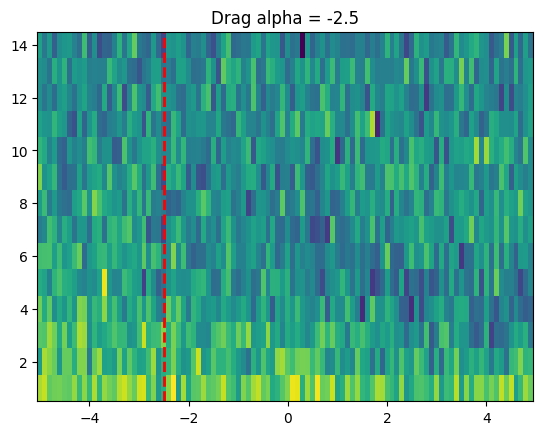

In [272]:
plt.pcolormesh(alpha, iter, np.abs(iq))
z=0
for i in range(len(iq)):
    z+=np.abs(iq[i])
plt.axvline(alpha[np.argmin(z)], color='r', ls='--', lw=2)
plt.title(f'Drag alpha = {alpha[np.argmin(z)]:.1f}')

config['alpha'] = round(alpha[np.argmin(z)],2)
config['delta'] = 0.3
run_cfg['alpha'] = round(alpha[np.argmin(z)],2)
run_cfg['delta'] =  0.3

# Ramsey Fringe Experiment

In [75]:
class RamseyProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        
        self.add_loop("waitloop", cfg["steps"])
        
        self.add_gauss(ch=res_ch, name="res_ramp",sigma=cfg['res_sigma'], length=5*cfg['res_sigma'], even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="res_ramp",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse1", ro_ch=ro_ch,
                        style="arb",
                        envelope="ramp",
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'],
                        gain=cfg['pi2_gain'],
                        )

            self.add_pulse(ch=qubit_ch, name="qubit_pulse2",ro_ch=ro_ch,
                        style="arb",
                        envelope="ramp",
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'] + cfg['wait_time']*360*cfg['ramsey_freq'],
                        gain=cfg['pi2_gain'],
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse1",ro_ch=ro_ch,
                        style="flat_top",
                        envelope="ramp", 
                        length = cfg['flat_top_len'],
                        freq=cfg['f_ge'],
                        phase= cfg['qubit_phase'],
                        gain=cfg['pi2_gain'],
                        )
            self.add_pulse(ch=qubit_ch, name="qubit_pulse2",ro_ch=ro_ch,
                        style="flat_top",
                        envelope="ramp",
                        length = cfg['flat_top_len'],
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'] + cfg['wait_time']*360*cfg['ramsey_freq'],
                        gain=cfg['pi2_gain'],
                        )
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse1", t=0)  
        
        self.delay_auto(cfg['wait_time'], tag='wait') 
        
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse2", t=0)  

        self.delay_auto(0.05) 
        
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) 
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [ ]:
START_TIME = 0. # [us]
STOP_TIME = 10# [us]
STEPS = 100

expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'wait_time': QickSweep1D('waitloop', START_TIME, STOP_TIME), # [us]
    'ramsey_freq':1,

    }

run_cfg = {**config, **expt_cfg}


  0%|          | 0/50 [00:00<?, ?it/s]

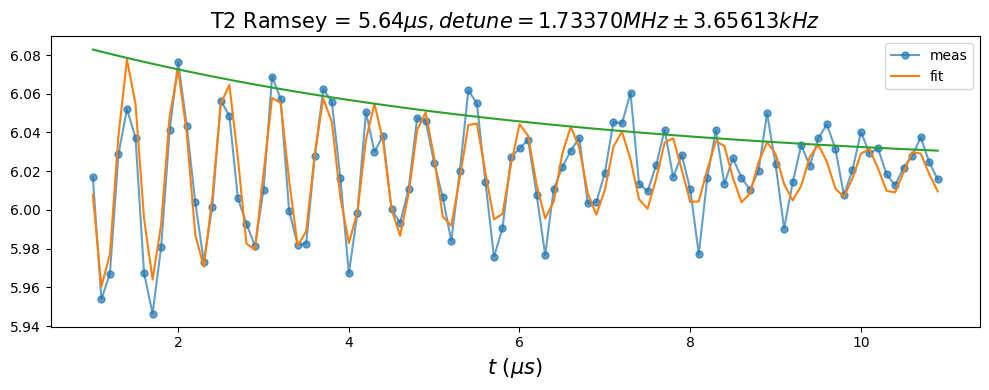

In [78]:
pyavg = 50

ramsey=RamseyProgram(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = ramsey.acquire(soc, rounds=pyavg, progress=True, threshold=run_cfg['thresholds'])
delay_times = ramsey.get_time_param('wait', "t", as_array=True)
ramsey = iq_list[0][0].dot([1,1j])

t2r = T2fring_analyze(delay_times, (ramsey), prefix='Ramsey')

In [22]:
activate_correct=True
if activate_correct:
    if abs(t2r[1]-run_cfg['ramsey_freq'])>0.0001:
        config['f_ge'] = config['f_ge']-round((t2r[1]-run_cfg['ramsey_freq']),5)
        print(f'over detune {round((t2r[1]-run_cfg["ramsey_freq"]),5)}')
        print('Correct')
    else:
        print(f'over detune {round((t2r[1]-run_cfg["ramsey_freq"]),5)}')

over detune -0.89391
Correct


In [ ]:
data_path = data_path
exp_name = f"q{qubit_idx+1} T2 Ramsey "

try:
        run_cfg.pop('wait_time')
except:
        pass

dict_val = yml_comment(run_cfg)

file_path = get_next_filename_labber(data_path, exp_name, Yoko_current)
hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Time', 'unit': "s",
                'values': delay_times*1e-6},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  iq_list[0][0].dot([1,1j])},
        comment=(f'Detune = {t2r[1]-run_cfg["ramsey_freq"]:.2f} MHz\
                \nRamsey Frequency =  {run_cfg["ramsey_freq"]:.2f}\
                \nT2R = {t2r[3]:.2f}us\
                \nYokogawa = {Yoko_current}mA\
                \n\n{dict_val}'),
        tag='T2')

# Spin Echo Experiment

In [149]:
class SpinEchoProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)

        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_loop("waitloop", cfg["steps"])

        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="const",
                       length=cfg['res_len'],
                       freq=cfg['f_res'],
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )

        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse1",
                        style="arb",
                        envelope="ramp",
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'],
                        gain=cfg['pi2_gain'],
                        )
            self.add_pulse(ch=qubit_ch, name="qubit_pulse_pi",
                        style="arb",
                        envelope="ramp",
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'],
                        gain=cfg['pi_gain'],
                        )
            self.add_pulse(ch=qubit_ch, name="qubit_pulse2",
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'], 
                        phase=cfg['qubit_phase']+ cfg['wait_time']*360*cfg['ramsey_freq'], 
                        gain=cfg['pi2_gain'], 
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse_pi", 
                           style="flat_top", 
                           envelope="ramp", 
                           length = cfg['flat_top_len'], 
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['pi_gain'],
                          )
            self.add_pulse(ch=qubit_ch, name="qubit_pulse1", 
                           style="flat_top", 
                           envelope="ramp", 
                           length = cfg['flat_top_len'],
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['pi2_gain'],
                          )
            self.add_pulse(ch=qubit_ch, name="qubit_pulse2", 
                           style="flat_top", 
                           envelope="ramp", 
                           length = cfg['flat_top_len'],
                           freq=cfg['f_ge'], 
                           phase=cfg['qubit_phase'] + cfg['wait_time']*360*cfg['ramsey_freq'], 
                           gain=cfg['pi2_gain'],
                          )
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse1", t=0)  #play pulse
        
        self.delay_auto((cfg['wait_time']/2)+0.01, tag = 'wait1') # wait_time after last pulse (wait / 2)
        
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse_pi", t=0)  #play pulse
        
        self.delay_auto((cfg['wait_time']/2)+0.01, tag = 'wait2') # wait_time after last pulse (wait / 2)

        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse2", t=0)  #play pulse

        self.delay_auto(0.01) # wait_time after last pulse
        
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) # play probe pulse
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [150]:
START_TIME = 0.0 # [us]
STOP_TIME = 10 # [us]
STEPS = 100

expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'ramsey_freq':0.8,
    'wait_time': QickSweep1D('waitloop', START_TIME, STOP_TIME), # [us]
    }

run_cfg = {**config, **expt_cfg}

  0%|          | 0/50 [00:00<?, ?it/s]

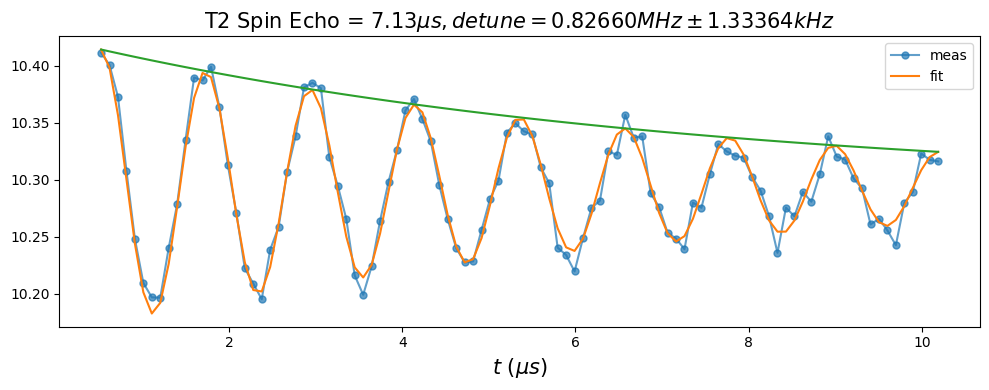

In [151]:
pyavg = 50

spinecho=SpinEchoProgram(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = spinecho.acquire(soc, rounds=pyavg, progress=True, threshold=run_cfg['thresholds'])
delay_times1 = spinecho.get_time_param('wait1', "t", as_array=True)
delay_times2 = spinecho.get_time_param('wait2', "t", as_array=True)
spinecho = iq_list[0][0].dot([1,1j])

t2e = T2fring_analyze(delay_times1+delay_times2, spinecho,  prefix='Spin Echo')

In [ ]:
data_path = data_path
exp_name = f"q{qubit_idx+1} T2 SpinEcho "

try:
        run_cfg.pop('wait_time')
except:
        pass

dict_val = yml_comment(run_cfg)

file_path = get_next_filename_labber(data_path, exp_name, Yoko_current)
hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Time', 'unit': "s",
                'values': (delay_times1+delay_times2)*1e-6},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  iq_list[0][0].dot([1,1j])},
        comment=(f'detune = {t2e[1]-run_cfg["ramsey_freq"]:.2f} MHz\
                \nRamsey Frequency =  {run_cfg["ramsey_freq"]:.2f}\
                \nT2E = {t2e[3]:.2f}us\
                \nYokogawa = {-4.2}mA\
                \n\n{dict_val}'),
        tag='T2')

# T1

In [25]:
class T1Program(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_loop("waitloop", cfg["steps"])


        self.add_gauss(ch=res_ch, name="res", sigma=0.01, length=0.01*5, even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="flat_top",
                       envelope='res',
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", ro_ch=ro_ch, 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'],
                        gain=cfg['pi_gain'], 
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", ro_ch=ro_ch, 
                           style="flat_top", 
                           envelope="ramp", 
                           length = cfg['flat_top_len'],
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['pi_gain'],

                          )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse", t=0)  #play pulse
        self.delay_auto(cfg['wait_time']+0.05, tag='wait') # wait_time after last pulse
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) # play probe pulse
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [26]:
START_TIME = 0.0 # [us]
STOP_TIME = 50.0 # [us]
STEPS = 50

expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'wait_time': QickSweep1D('waitloop', START_TIME, STOP_TIME), # [us]
    'relax_delay': 50,
    }

run_cfg = {**config, **expt_cfg}

  0%|          | 0/50 [00:00<?, ?it/s]

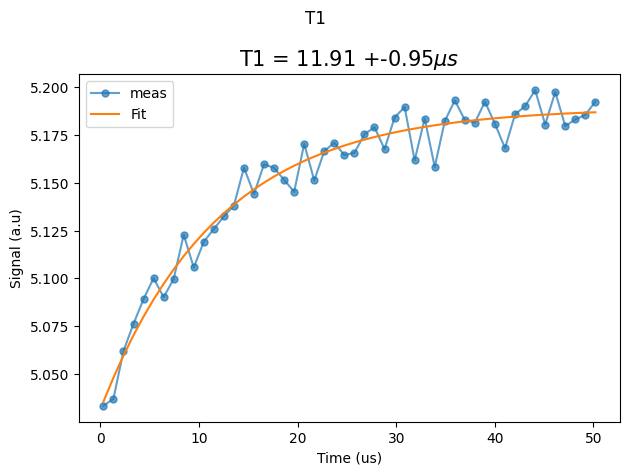

In [27]:
pyavg = 50
T1=T1Program(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
# iq_list = T1.acquire(soc, soft_avgs=pyavg, progress=True, threshold=run_cfg['thresholds'])
iq_list = T1.acquire(soc, rounds=pyavg, progress=True)
delay_times = T1.get_time_param('wait', "t", as_array=True)

t1 = T1_analyze(delay_times, (iq_list[0][0].dot([1,1j])))

In [ ]:
data_path = data_path
exp_name = f"q{qubit_idx+1} ef T1"

try:
        run_cfg.pop('wait_time')
except:
        pass

dict_val = yml_comment(run_cfg)

file_path = get_next_filename_labber(data_path, exp_name, Yoko_current)
hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Time', 'unit': "s",
                'values': delay_times*1e-6},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  iq_list[0][0].dot([1,1j])},
        comment=f'T1 = {t1[3]:.2f}us,\
                \nYokogawa = {Yoko_current}mA\
                \n\n {dict_val}',
        tag='T1')

# ALL XY

In [44]:
class AllXY(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        
        self.add_gauss(ch=res_ch, name="res_ramp",sigma=cfg['res_sigma'], length=5*cfg['res_sigma'], even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="res_ramp",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="x180", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=0,
                        gain=cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="x90", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=0,
                    gain=cfg['pi2_gain'], 
                    )
            self.add_pulse(ch=qubit_ch, name="y180", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=90,
                        gain=cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="y90", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=90,
                    gain=cfg['pi2_gain'], 
                    )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="x180", 
                        style="flat_top", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=0,
                        gain=cfg['pi_gain'], 
                        length = cfg['flat_top_len'],
                        )
            self.add_pulse(ch=qubit_ch, name="x90", 
                    style="flat_top", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=0,
                    gain=cfg['pi2_gain'], 
                    length = cfg['flat_top_len'],
                    )
            self.add_pulse(ch=qubit_ch, name="y180", 
                        style="flat_top", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=90,
                        gain=cfg['pi_gain'], 
                        length = cfg['flat_top_len'],
                        )
            self.add_pulse(ch=qubit_ch, name="y90", 
                    style="flat_top", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=90,
                    gain=cfg['pi2_gain'], 
                    length = cfg['flat_top_len'],
                    )
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        if cfg['allxy_gates'][0]=='I':
            pass 
        else:
            self.pulse(ch=self.cfg["qubit_ch"], name=f"{self.cfg['allxy_gates'][0]}", t=0) 
        self.delay_auto(0.01) 
        if cfg['allxy_gates'][1]=='I':
            pass 
        else:
            self.pulse(ch=self.cfg["qubit_ch"], name=f"{self.cfg['allxy_gates'][1]}", t=0) 
        
        self.delay_auto(0.05) # wait_time after last pulse
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) # play probe pulse
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [45]:
sequence = [
    ("I", "I"),
    ("x180", "x180"),
    ("y180", "y180"),
    ("x180", "y180"),
    ("y180", "x180"),
    ("x90", "I"),
    ("y90", "I"),
    ("x90", "y90"),
    ("y90", "x90"),
    ("x90", "y180"),
    ("y90", "x180"),
    ("x180", "y90"),
    ("y180", "x90"),
    ("x90", "x180"),
    ("x180", "x90"),
    ("y90", "y180"),
    ("y180", "y90"),
    ("x180", "I"),
    ("y180", "I"),
    ("x90", "x90"),
    ("y90", "y90"),
]


  0%|          | 0/21 [00:00<?, ?it/s]

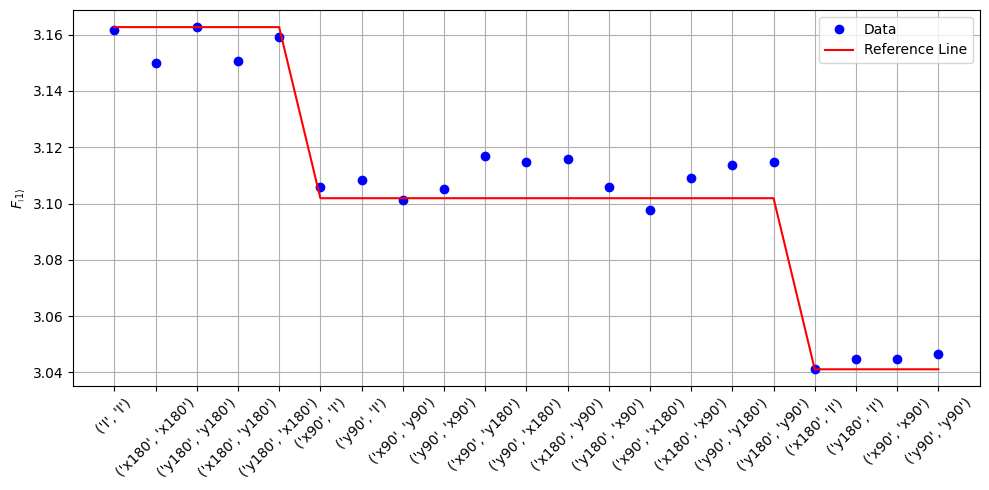

In [48]:

run_cfg = {**config}
pyavg = 30

allxy_lst=[]
for gate in tqdm(sequence):
    run_cfg['allxy_gates'] = gate
    allxy=AllXY(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
    iq_list = allxy.acquire(soc, rounds=pyavg, progress=False, threshold=run_cfg['thresholds'])
    allxy_lst.append(iq_list[0][0].dot([1,1j]))

amp = np.abs(allxy_lst)
plt.figure(figsize=(10, 5))
plt.plot(amp, 'bo', label='Data')
plt.plot([np.max(amp)]*5 + [0.5*(np.max(amp)+np.min(amp))]*12 + [np.min(amp)]*4, 'r-', label='Reference Line')
plt.xticks(np.arange(len(sequence)), sequence, rotation=45)
plt.ylabel(r'$F_{\left|1\right\rangle}$')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

# tomography (under test)

In [49]:
class StateTomographyCal(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']

        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type'] == 'axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])

        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        # readout pulse
        self.add_gauss(ch=res_ch, name="res_ramp", sigma=cfg['res_sigma'], length=5*cfg['res_sigma'], even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top", envelope="res_ramp",
                       length=cfg['res_len'], freq=cfg['f_res'],
                       phase=cfg['res_phase'], gain=cfg['res_gain'])

        # qubit pulses
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        self.add_pulse(ch=qubit_ch, name="x180", style="arb", envelope="ramp", freq=cfg['f_ge'], phase=0,   gain=cfg['pi_gain'])
        self.add_pulse(ch=qubit_ch, name="x90",  style="arb", envelope="ramp", freq=cfg['f_ge'], phase=0,   gain=cfg['pi2_gain'])
        self.add_pulse(ch=qubit_ch, name="x90m", style="arb", envelope="ramp", freq=cfg['f_ge'], phase=0,   gain=-cfg['pi2_gain']) # R_x(-π/2)
        self.add_pulse(ch=qubit_ch, name="y90",  style="arb", envelope="ramp", freq=cfg['f_ge'], phase=+90, gain=cfg['pi2_gain'])
        self.add_pulse(ch=qubit_ch, name="y90m", style="arb", envelope="ramp", freq=cfg['f_ge'], phase=-90, gain=cfg['pi2_gain'])

    def _body(self, cfg):
        qs  = cfg['qubit_ch']
        ros = cfg['ro_ch']

        prep = cfg.get("prep_state", "0")   # "0","1","+X","-X","+Y","-Y"
        axis = cfg.get("meas_axis", "Z")    # "X","Y","Z"

        self.send_readoutconfig(ch=ros, name="myro", t=0)

        # ===== prepare =====
        if prep == "1":
            self.pulse(ch=qs, name="x180", t=0)
            self.delay_auto(0.01)
        elif prep == "+X":
            self.pulse(ch=qs, name="y90",  t=0)
            self.delay_auto(0.01)
        elif prep == "-X":
            self.pulse(ch=qs, name="y90m", t=0)
            self.delay_auto(0.01)
        elif prep == "+Y":
            self.pulse(ch=qs, name="x90",  t=0)
            self.delay_auto(0.01)
        elif prep == "-Y":
            self.pulse(ch=qs, name="x90m", t=0)
            self.delay_auto(0.01)
        elif prep == "0":
            pass

        # ===== tomography pre-rotation =====
        if axis == "X":
            self.pulse(ch=qs, name="y90m", t=0)
            self.delay_auto(0.01)
        elif axis == "Y":
            self.pulse(ch=qs, name="x90",  t=0)
            self.delay_auto(0.01)
        elif axis == "Z":
            pass


        self.delay_auto(0.05)
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[ros], pins=[0], t=cfg['trig_time'])


In [53]:

def calibrate_iq(iq, iq0, iq1):
    proj_vec = (iq1 - iq0) / np.abs(iq1 - iq0)
    proj = np.real((iq - iq0) * np.conj(proj_vec))
    scale = np.real((iq1 - iq0) * np.conj(proj_vec))
    return np.clip(proj / scale, 0, 1)

def measure_xyz_moment(soc, soccfg, run_cfg, pyavg, iq0, iq1):
    m = {}
    iq_raw = {}
    for axis in ["X","Y","Z"]:
        run_cfg["meas_axis"] = axis
        prog = StateTomographyCal(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = prog.acquire(soc, rounds=pyavg, progress=False)
        iq = iq_list[0][0].dot([1, 1j])
        p1 = float(calibrate_iq(iq, iq0, iq1))
        m[axis] = 1.0 - 2.0*p1   # P1 -> <sigma>
        iq_raw[axis] = iq
    return np.array([m["X"], m["Y"], m["Z"]], float), iq_raw


In [55]:
pyavg = 50
normalize_axis=True
config['res_gain'] = 0.6
config['ro_len'] = 2
run_cfg = {**config}


if normalize_axis:
    print('--------normalize axis--------')
    print('prepare ground state')
    run_cfg["prep_state"] = "0"
    run_cfg["meas_axis"] = "Z"
    prog = StateTomographyCal(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
    iq0 = prog.acquire(soc, rounds=pyavg, progress=True)[0][0].dot([1,1j])

    print('prepare excited state')
    run_cfg["prep_state"] = "1"
    run_cfg["meas_axis"] = "Z"
    prog = StateTomographyCal(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
    iq1 = prog.acquire(soc, rounds=pyavg, progress=True)[0][0].dot([1,1j])
    print(f'Finish, iq0={iq0}, iq1={iq1}')

cal_states = [
    ("0",  np.array([0., 0., +1.])),
    ("1",  np.array([0., 0., -1.])),
    ("+X", np.array([+1.,0., 0.])),
    ("-X", np.array([-1.,0., 0.])),
    ("+Y", np.array([0., +1.,0.])),
    ("-Y", np.array([0., -1.,0.])),
]

M_meas = []
R_true = [] 
for name, r_true in tqdm(cal_states, desc='states calibration'):
    print(f'Calibrating state {name}')
    run_cfg["prep_state"] = name
    m_vec, _ = measure_xyz_moment(soc, soccfg, run_cfg, pyavg=pyavg, iq0=iq0, iq1=iq1)
    M_meas.append(m_vec)
    R_true.append(r_true)

M_meas = np.vstack(M_meas)
R_true = np.vstack(R_true)


--------normalize axis--------
prepare ground state


  0%|          | 0/50 [00:00<?, ?it/s]

prepare excited state


  0%|          | 0/50 [00:00<?, ?it/s]

Finish, iq0=(3.6875358306188923-4.700701628664494j), iq1=(3.2777052117263836-4.705848534201953j)


states calibration:   0%|          | 0/6 [00:00<?, ?it/s]

Calibrating state 0
Calibrating state 1
Calibrating state +X
Calibrating state -X
Calibrating state +Y
Calibrating state -Y


In [56]:

R_ext = np.hstack([R_true, np.ones((R_true.shape[0],1))]) 

A = np.zeros((3,3))
b = np.zeros(3)
for j in range(3): 
    x, *_ = np.linalg.lstsq(R_ext, M_meas[:, j], rcond=None)
    A[:, j] = x[:3]
    b[j]    = x[3]
A = A.T


pred = (R_true @ A.T) + b   # (N,3)
res  = M_meas - pred
print("A=\n", A)
print("b=", b)
print("RMSE per axis =", np.sqrt((res**2).mean(axis=0)))

A=
 [[ 0.9565958  -0.11480674  0.05324754]
 [ 0.00153518 -1.          0.03584157]
 [ 0.04871286 -0.0458648   0.99230147]]
b= [-0.00732762 -0.00019768  0.03133993]
RMSE per axis = [0.05868346 0.02460487 0.05177437]


In [57]:
run_cfg["prep_state"] = "1" 
m_unknown, iq_xyz = measure_xyz_moment(soc, soccfg, run_cfg, pyavg=pyavg, iq0=iq0, iq1=iq1)


r_est = np.linalg.solve(A, (m_unknown - b))
nr = np.linalg.norm(r_est)
if nr > 1 + 1e-10:
    r_est = r_est / nr * 0.999999


rx, ry, rz = r_est
rho = 0.5 * np.array([[1+rz,      rx - 1j*ry],
                      [rx + 1j*ry, 1-rz]], dtype=complex)


vals, vecs = np.linalg.eigh(rho)
vals = np.clip(vals, 0, None)
rho_phys = (vecs * (vals/vals.sum() if vals.sum()>0 else vals)) @ vecs.conj().T

purity = float(np.real(np.trace(rho_phys @ rho_phys)))
print("m_meas =", m_unknown, " | r_est =", r_est, " ||r||=", np.linalg.norm(r_est))
print("rho =\n", rho_phys)
print("eigvals =", np.linalg.eigvalsh(rho_phys))
print("purity =", round(purity*100, 4), "%")


m_meas = [-0.00526064 -0.04094892 -0.98003552]  | r_est = [ 0.05817361  0.00411681 -0.99829699]  ||r||= 0.9999989999999997
rho =
 [[8.51504340e-04+0.00000000e+00j 2.90868055e-02-2.05840406e-03j]
 [2.90868055e-02+2.05840406e-03j 9.99148496e-01-1.38777878e-17j]]
eigvals = [5.000000e-07 9.999995e-01]
purity = 99.9999 %


C:\Users\QEL\AppData\Local\Temp\ipykernel_63844\3880770958.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  facecolors = cm.get_cmap(phase_cmap)(phs_norm.flatten())


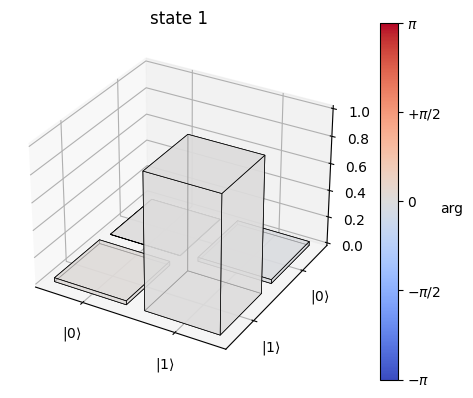

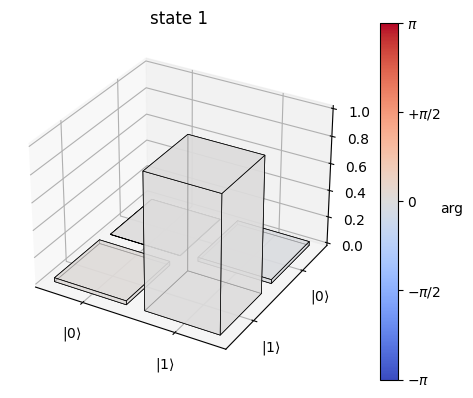

In [58]:

from matplotlib import cm, colors

def plot_density_matrix(rho, title=f'state {run_cfg["prep_state"]}', phase_cmap="coolwarm", show=True):
    rho = np.asarray(rho, dtype=complex)
    amp = np.abs(rho)
    phs = np.angle(rho)
    phs_norm = (phs + np.pi)/(2*np.pi)

    xs, ys = np.meshgrid([0,1],[1,0])
    xs = xs.flatten(); ys = ys.flatten()
    zs = np.zeros_like(xs, dtype=float)
    dx = dy = 0.8
    dz = amp.flatten()

    facecolors = cm.get_cmap(phase_cmap)(phs_norm.flatten())

    fig = plt.figure(figsize=(5,5))
    ax = fig.add_subplot(111, projection='3d')
    ax.bar3d(xs-0.4, ys-0.4, zs, dx, dy, dz,
             shade=False, color=facecolors, edgecolor="k", linewidth=0.5,alpha=0.7)

    ax.set_zlim(0, 1.0)
    ax.set_xticks([0,1]); ax.set_xticklabels([r"$|0\rangle$", r"$|1\rangle$"])
    ax.set_yticks([0,1]); ax.set_yticklabels([r"$|1\rangle$", r"$|0\rangle$"])
    ax.set_title(title, pad=6)

    # phase colorbar
    norm = colors.Normalize(vmin=-np.pi, vmax=np.pi)
    mappable = cm.ScalarMappable(norm=norm, cmap=phase_cmap)
    cbar = fig.colorbar(mappable, ax=ax, fraction=0.046, pad=0.08)
    cbar.set_label("arg", rotation=0, labelpad=8)
    cbar.set_ticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    cbar.set_ticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$+\pi/2$", r"$\pi$"])

    return fig


plot_density_matrix(rho_phys)


C:\Users\QEL\AppData\Local\Temp\ipykernel_63844\89984344.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap(phase_cmap)


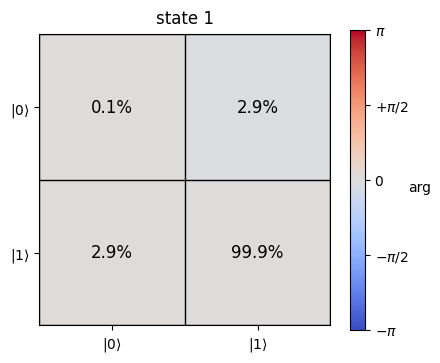

In [59]:

def plot_density_matrix_2d(rho, title=f'state {run_cfg["prep_state"]}',
                           phase_cmap="coolwarm", annotate_decimals=1,
                           alpha_by_amp=False, show=True):
    """
    以 2D 方格顯示密度矩陣：
    - 顏色代表相位（-π ~ +π）
    - 方格中央標示 |rho_ij| 的百分比
    - 可選：用透明度表示幅值 (alpha_by_amp=True)
    """
    rho = np.asarray(rho, dtype=complex)
    assert rho.shape == (2,2), "此版本針對 2×2 密度矩陣"
    amp = np.abs(rho)
    phs = np.angle(rho)

    # 配色：以相位著色
    cmap = cm.get_cmap(phase_cmap)
    norm = colors.Normalize(vmin=-np.pi, vmax=np.pi)
    rgba = cmap(norm(phs))

    # 可選：以 alpha 呈現幅值（避免全透明，留 0.25~1.0）
    if alpha_by_amp:
        a = 0.25 + 0.75 * (amp / (amp.max() if amp.max() > 0 else 1.0))
        rgba[..., -1] = a

    fig, ax = plt.subplots(figsize=(4.2, 4.2))
    ax.imshow(rgba, origin="upper", interpolation="none")

    # 格線（畫出每個 cell 的邊界）
    ax.set_xticks(np.arange(-0.5, 2, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 2, 1), minor=True)
    ax.grid(which="minor", color="k", linestyle="-", linewidth=1.0)
    ax.tick_params(which="minor", bottom=False, left=False)

    # 主要刻度與標籤（|0>, |1>）
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels([r"$|0\rangle$", r"$|1\rangle$"])
    ax.set_yticklabels([r"$|0\rangle$", r"$|1\rangle$"])

    # 在每個方格中央標上幅值百分比
    # 依底色亮度自動選擇黑/白字
    for i in range(2):
        for j in range(2):
            r, g, b, _ = rgba[i, j]
            # sRGB 亮度估計
            lum = 0.299*r + 0.587*g + 0.114*b
            txt_color = "k" if lum > 0.55 else "w"
            pct = 100.0 * amp[i, j]
            ax.text(j, i, f"{pct:.{annotate_decimals}f}%",
                    ha="center", va="center", fontsize=12, color=txt_color)

    # 顯示相位色條
    mappable = cm.ScalarMappable(norm=norm, cmap=phase_cmap)
    cbar = fig.colorbar(mappable, ax=ax, fraction=0.046, pad=0.06)
    cbar.set_label("arg", rotation=0, labelpad=8)
    cbar.set_ticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    cbar.set_ticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$+\pi/2$", r"$\pi$"])

    ax.set_title(title, pad=8)
    ax.set_xlim(-0.5, 1.5); ax.set_ylim(1.5, -0.5)  # 保持方格完整顯示

    if show:
        plt.show()
    return fig

# 用法：
fig = plot_density_matrix_2d(rho_phys, phase_cmap="coolwarm", annotate_decimals=1)


In [60]:
def make_rho(r_est):
    """r_est shape: (3, N)"""
    rx, ry, rz = r_est
    N = rx.shape[0]
    rho_all = np.zeros((N, 2, 2), dtype=complex)
    rho_all[:,0,0] = 0.5*(1+rz)
    rho_all[:,1,1] = 0.5*(1-rz)
    rho_all[:,0,1] = 0.5*(rx - 1j*ry)
    rho_all[:,1,0] = 0.5*(rx + 1j*ry)
    return rho_all

def project_to_physical(rho_all):
    """修正密度矩陣確保正定"""
    rho_phys_all = []
    for rho in rho_all:
        vals, vecs = np.linalg.eigh(rho)
        vals = np.clip(vals, 0, None)
        vals = vals / vals.sum() if vals.sum() > 0 else vals
        rho_phys = (vecs * vals) @ vecs.conj().T
        rho_phys_all.append(rho_phys)
    return np.array(rho_phys_all)

def calc_purity(rho_phys_all):
    return np.real([np.trace(r @ r) for r in rho_phys_all])



In [61]:
class StateTomographyRabi(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']

        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type'] == 'axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])

        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_loop("gainloop", cfg["steps"])
        # readout pulse
        self.add_gauss(ch=res_ch, name="res_ramp", sigma=cfg['res_sigma'], length=5*cfg['res_sigma'], even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top", envelope="res_ramp",
                       length=cfg['res_len'], freq=cfg['f_res'],
                       phase=cfg['res_phase'], gain=cfg['res_gain'])

        # qubit pulses
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        self.add_pulse(ch=qubit_ch, name="x180", style="arb", envelope="ramp", freq=cfg['f_ge'], phase=0,   gain=cfg['pi_gain'])
        self.add_pulse(ch=qubit_ch, name="x90",  style="arb", envelope="ramp", freq=cfg['f_ge'], phase=0,   gain=cfg['pi2_gain'])
        self.add_pulse(ch=qubit_ch, name="x90m", style="arb", envelope="ramp", freq=cfg['f_ge'], phase=0,   gain=-cfg['pi2_gain']) # R_x(-π/2)
        self.add_pulse(ch=qubit_ch, name="y90",  style="arb", envelope="ramp", freq=cfg['f_ge'], phase=+90, gain=cfg['pi2_gain'])
        self.add_pulse(ch=qubit_ch, name="y90m", style="arb", envelope="ramp", freq=cfg['f_ge'], phase=-90, gain=cfg['pi2_gain'])

    def _body(self, cfg):
        qs  = cfg['qubit_ch']
        ros = cfg['ro_ch']

        # 兩個關鍵參數（改成用 get，並給預設）
        prep = cfg.get("prep_state", "0")   # "0","1","+X","-X","+Y","-Y"
        axis = cfg.get("meas_axis", "Z")    # "X","Y","Z"

        self.send_readoutconfig(ch=ros, name="myro", t=0)

        # ===== (A) 狀態準備 =====
        if prep == "1":
            self.pulse(ch=qs, name="x180", t=0)
            self.delay_auto(0.01)
        elif prep == "+X":
            self.pulse(ch=qs, name="y90",  t=0)
            self.delay_auto(0.01)
        elif prep == "-X":
            self.pulse(ch=qs, name="y90m", t=0)
            self.delay_auto(0.01)
        elif prep == "+Y":
            self.pulse(ch=qs, name="x90",  t=0)
            self.delay_auto(0.01)
        elif prep == "-Y":
            self.pulse(ch=qs, name="x90m", t=0)
            self.delay_auto(0.01)
        elif prep == "0":   
            pass
        self.delay_auto(0.05)
        # ===== tomography pre-rotation =====
        if axis == "X":
            self.pulse(ch=qs, name="y90m", t=0)  # 量 X
            self.delay_auto(0.01)
        elif axis == "Y":
            self.pulse(ch=qs, name="x90",  t=0)  # 量 Y
            self.delay_auto(0.01)
        elif axis == "Z":
            pass    


        self.delay_auto(0.05)
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[ros], pins=[0], t=cfg['trig_time'])

def measure_xyz_moment_Rabi(soc, soccfg, run_cfg, pyavg, iq0, iq1):
    """固定 prep_state，掃 X/Y/Z，回傳 m=[mx,my,mz] 與原始 IQ 字典"""
    m = {}
    iq_raw = {}
    for axis in tqdm(["X","Y","Z"]):
        run_cfg["meas_axis"] = axis
        prog = StateTomographyRabi(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = prog.acquire(soc, rounds=pyavg, progress=True)
        iq = iq_list[0][0].dot([1, 1j])
        p1 = calibrate_iq(iq, iq0, iq1)
        m[axis] = 1.0 - 2.0*p1   # P1 -> <sigma>
        iq_raw[axis] = iq
        # p1_raw[axis] = p1_array
    return np.array([m["X"], m["Y"], m["Z"]], float), iq_raw

STEPS = 100
pyavg = 50

expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'relax_delay': 50,
    'pi_gain': QickSweep1D('gainloop', 0, 1), # [DAC units]

    }

run_cfg = {**config, **expt_cfg}
run_cfg["prep_state"] = "1" 

m_unknown, iq_xyz = measure_xyz_moment_Rabi(soc, soccfg, run_cfg, pyavg=pyavg, iq0=iq0, iq1=iq1)

r_est_list = []
for i in range(m_unknown.shape[1]):
    r = np.linalg.solve(A, m_unknown[:, i] - b)
    nr = np.linalg.norm(r)
    if nr > 1 + 1e-10:
        r = r / nr * 0.999999
    r_est_list.append(r)

r_est = np.array(r_est_list).T   # shape = (3, N)

rho_all = make_rho(r_est)              # (N,2,2)
rho_phys_all = project_to_physical(rho_all)
purity_all = calc_purity(rho_phys_all) # shape (N,)


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

In [63]:
purity_all

array([0.75270506, 0.85645161, 0.86632216, 0.999999  , 0.96097717,
       0.999999  , 0.999999  , 0.999999  , 0.999999  , 0.999999  ,
       0.999999  , 0.999999  , 0.999999  , 0.999999  , 0.999999  ,
       0.999999  , 0.999999  , 0.999999  , 0.999999  , 0.999999  ,
       0.999999  , 0.999999  , 0.999999  , 0.999999  , 0.999999  ,
       0.999999  , 0.999999  , 0.999999  , 0.999999  , 0.999999  ,
       0.93656387, 0.999999  , 0.999999  , 0.95163025, 0.89780715,
       0.8921451 , 0.85279516, 0.85514918, 0.75401439, 0.78613344,
       0.7198653 , 0.78575939, 0.81441058, 0.78715878, 0.82427653,
       0.75873348, 0.87547546, 0.87772878, 0.99236997, 0.999999  ,
       0.999999  , 0.999999  , 0.999999  , 0.999999  , 0.999999  ,
       0.999999  , 0.999999  , 0.999999  , 0.999999  , 0.999999  ,
       0.999999  , 0.999999  , 0.999999  , 0.999999  , 0.999999  ,
       0.999999  , 0.999999  , 0.999999  , 0.999999  , 0.999999  ,
       0.999999  , 0.999999  , 0.999999  , 0.999999  , 0.99999

c:\Users\QEL\Anaconda3\envs\qick\lib\site-packages\matplotlib\cbook\__init__.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


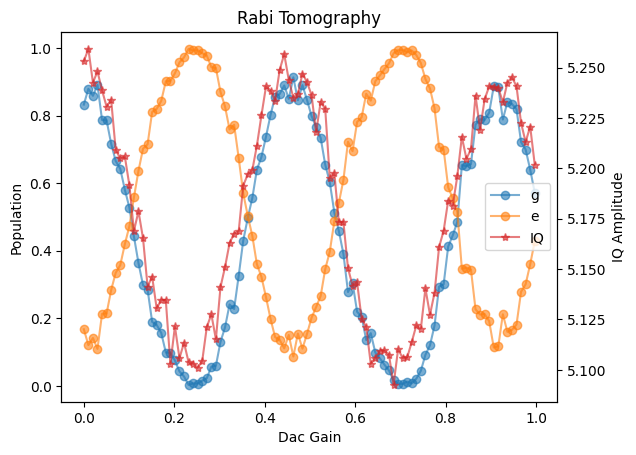

In [62]:
fig, ax1 = plt.subplots()


ax1.set_title('Rabi Tomography')
ax1.plot(gains, rho_phys_all[:,0,0], label='g', marker='o', alpha=0.6)
ax1.plot(gains, rho_phys_all[:,1,1], label='e', marker='o', alpha=0.6)

ax1.set_xlabel('Dac Gain')
ax1.set_ylabel('Population')
ax1.legend(loc='upper left')


ax2 = ax1.twinx()
ax2.plot(gains, np.abs(power_rabi), label='IQ', marker='*', alpha=0.6, color='tab:red')
ax2.set_ylabel('IQ Amplitude')


lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')



In [534]:
np.savez("rabi_tomography.npz", rho=rho_phys_all, gains=gains, acquiredata = power_rabi)
np.savez("tomography_cal.npz", iq0=iq0, iq1=iq1, M_meas=M_meas, R_true=R_true, A=A, b=b)

In [528]:

prog = StateTomographyRabi(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
gains = prog.get_pulse_param('x180', "gain", as_array=True)

import imageio, os
out_dir = "Rabi_Tomography"
os.makedirs(out_dir, exist_ok=True)
png_paths = []
for idx, gain in enumerate(gains):
    title = f'gain={gain:.4f}, prep={run_cfg.get("prep_state","1")}'
    fig = plot_density_matrix(rho_phys_all[idx], title=title, phase_cmap="coolwarm", show=False)
    png_path = os.path.join(out_dir, f"frame_{idx:03d}.png")
    fig.savefig(png_path, dpi=180, bbox_inches="tight")
    plt.close(fig)
    png_paths.append(png_path)

# === 3) 合成 GIF（duration=每張停留秒數；越大越慢）===
images = [imageio.imread(p) for p in png_paths]
imageio.mimsave("Rabi.gif", images, fps=5, loop=0) # loop=0 無限循環
print("Saved to Rabi.gif")

C:\Users\QEL\AppData\Local\Temp\ipykernel_63372\3880770958.py:15: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.

C:\Users\QEL\AppData\Local\Temp\ipykernel_63372\308945468.py:17: DeprecationWarning:

Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.



Saved to Rabi.gif


# Test tomography

In [624]:
class StateTomographyT1(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']

        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type'] == 'axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])

        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_loop("waitloop", cfg["steps"])
        # readout pulse
        self.add_gauss(ch=res_ch, name="res_ramp", sigma=cfg['res_sigma'], length=5*cfg['res_sigma'], even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top", envelope="res_ramp",
                       length=cfg['res_len'], freq=cfg['f_res'],
                       phase=cfg['res_phase'], gain=cfg['res_gain'])

        # qubit pulses
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        self.add_pulse(ch=qubit_ch, name="x180", style="arb", envelope="ramp", freq=cfg['f_ge'], phase=0,   gain=cfg['pi_gain'])
        self.add_pulse(ch=qubit_ch, name="x90",  style="arb", envelope="ramp", freq=cfg['f_ge'], phase=0,   gain=cfg['pi2_gain'])
        self.add_pulse(ch=qubit_ch, name="x90m", style="arb", envelope="ramp", freq=cfg['f_ge'], phase=0,   gain=-cfg['pi2_gain']) # R_x(-π/2)
        self.add_pulse(ch=qubit_ch, name="y90",  style="arb", envelope="ramp", freq=cfg['f_ge'], phase=+90, gain=cfg['pi2_gain'])
        self.add_pulse(ch=qubit_ch, name="y90m", style="arb", envelope="ramp", freq=cfg['f_ge'], phase=-90, gain=cfg['pi2_gain'])

    def _body(self, cfg):
        qs  = cfg['qubit_ch']
        ros = cfg['ro_ch']

        # 兩個關鍵參數（改成用 get，並給預設）
        prep = cfg.get("prep_state", "0")   # "0","1","+X","-X","+Y","-Y"
        axis = cfg.get("meas_axis", "Z")    # "X","Y","Z"

        self.send_readoutconfig(ch=ros, name="myro", t=0)

        # ===== (A) 狀態準備 =====
        if prep == "1":
            self.pulse(ch=qs, name="x180", t=0)
            self.delay_auto(0.01)
        elif prep == "+X":
            self.pulse(ch=qs, name="y90",  t=0)
            self.delay_auto(0.01)
        elif prep == "-X":
            self.pulse(ch=qs, name="y90m", t=0)
            self.delay_auto(0.01)
        elif prep == "+Y":
            self.pulse(ch=qs, name="x90",  t=0)
            self.delay_auto(0.01)
        elif prep == "-Y":
            self.pulse(ch=qs, name="x90m", t=0)
            self.delay_auto(0.01)
        elif prep == "0":   
            pass
        self.delay_auto(cfg['wait_time']+0.05, tag='wait')
        # ===== tomography pre-rotation =====
        if axis == "X":
            self.pulse(ch=qs, name="y90m", t=0)  # 量 X
            self.delay_auto(0.01)
        elif axis == "Y":
            self.pulse(ch=qs, name="x90",  t=0)  # 量 Y
            self.delay_auto(0.01)
        elif axis == "Z":
            pass    


        self.delay_auto(0.05)
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[ros], pins=[0], t=cfg['trig_time'])

In [625]:
def measure_xyz_moment_T1(soc, soccfg, run_cfg, pyavg, iq0, iq1):
    """固定 prep_state，掃 X/Y/Z，回傳 m=[mx,my,mz] 與原始 IQ 字典"""
    m = {}
    iq_raw = {}
    for axis in tqdm(["X","Y","Z"]):
        run_cfg["meas_axis"] = axis
        prog = StateTomographyT1(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = prog.acquire(soc, rounds=pyavg, progress=True)
        iq = iq_list[0][0].dot([1, 1j])
        p1 = calibrate_iq(iq, iq0, iq1)
        m[axis] = 1.0 - 2.0*p1   # P1 -> <sigma>
        iq_raw[axis] = iq
    return np.array([m["X"], m["Y"], m["Z"]], float), iq_raw


In [626]:
START_TIME = 0.0 # [us]
STOP_TIME = 50.0 # [us]
STEPS = 100
pyavg = 50

expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'wait_time': QickSweep1D('waitloop' ,START_TIME, STOP_TIME), # [us]
    'relax_delay': 50,
    }

run_cfg = {**config, **expt_cfg}
run_cfg["prep_state"] = "1" 

m_unknown, iq_xyz = measure_xyz_moment_T1(soc, soccfg, run_cfg, pyavg=pyavg, iq0=iq0, iq1=iq1)


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

In [627]:
r_est_list = []
for i in range(m_unknown.shape[1]):
    r = np.linalg.solve(A, m_unknown[:, i] - b)
    nr = np.linalg.norm(r)
    if nr > 1 + 1e-10:
        r = r / nr * 0.999999
    r_est_list.append(r)

r_est = np.array(r_est_list).T   # shape = (3, N)

rho_all = make_rho(r_est)              # (N,2,2)
rho_phys_all = project_to_physical(rho_all)
purity_all = calc_purity(rho_phys_all) # shape (N,)


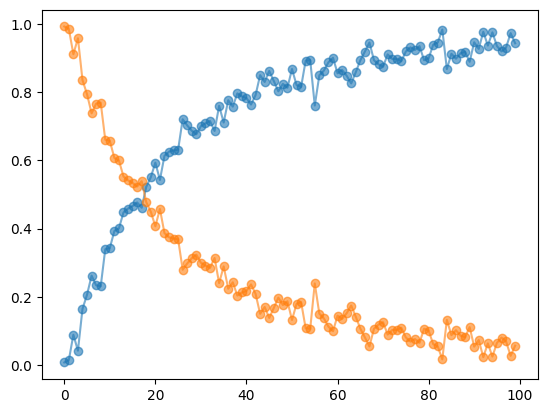

In [628]:
plt.plot(rho_phys_all[:,0,0], label='g', marker='o', alpha=0.6)
plt.plot(rho_phys_all[:,1,1], label='e', marker='o', alpha=0.6)

In [565]:
prog = StateTomographyT1(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
delay_times = prog.get_time_param('wait', "t", as_array=True)


In [ ]:

out_dir = "T1_Tomography"
os.makedirs(out_dir, exist_ok=True)
png_paths = []
for idx, times in enumerate(delay_times):
    title = f't={times:.1f} μs, prep={run_cfg.get("prep_state","1")}'
    fig = plot_density_matrix(rho_phys_all[idx], title=title, phase_cmap="coolwarm", show=False)
    png_path = os.path.join(out_dir, f"frame_{idx:03d}.png")
    fig.savefig(png_path, dpi=180, bbox_inches="tight")
    plt.close(fig)
    png_paths.append(png_path)

# === 3) 合成 GIF（duration=每張停留秒數；越大越慢）===
images = [imageio.imread(p) for p in png_paths]
imageio.mimsave("T1_pX.gif", images, fps=3, loop=0) # loop=0 無限循環
print("Saved to T1_pX.gif")

C:\Users\QEL\AppData\Local\Temp\ipykernel_63372\3880770958.py:15: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.

C:\Users\QEL\AppData\Local\Temp\ipykernel_63372\2188912490.py:14: DeprecationWarning:

Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.



Saved to T1_pX.gif


# Test tomography T2

In [629]:
class StateTomographyT2(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']

        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type'] == 'axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])

        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        
        self.add_loop("waitloop", cfg["steps"])
        # readout pulse
        self.add_gauss(ch=res_ch, name="res_ramp", sigma=cfg['res_sigma'], length=5*cfg['res_sigma'], even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top", envelope="res_ramp",
                       length=cfg['res_len'], freq=cfg['f_res'],
                       phase=cfg['res_phase'], gain=cfg['res_gain'])

        # qubit pulses
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        self.add_pulse(ch=qubit_ch, name="x180", style="arb", envelope="ramp", freq=cfg['f_ge'], phase=0,   gain=cfg['pi_gain'])
        self.add_pulse(ch=qubit_ch, name="x90",  style="arb", envelope="ramp", freq=cfg['f_ge'], phase=0,   gain=cfg['pi2_gain'])
        self.add_pulse(ch=qubit_ch, name="x90m", style="arb", envelope="ramp", freq=cfg['f_ge'], phase=0,   gain=-cfg['pi2_gain']) # R_x(-π/2)
        self.add_pulse(ch=qubit_ch, name="y90",  style="arb", envelope="ramp", freq=cfg['f_ge'], phase=+90, gain=cfg['pi2_gain'])
        self.add_pulse(ch=qubit_ch, name="y90m", style="arb", envelope="ramp", freq=cfg['f_ge'], phase=-90, gain=cfg['pi2_gain'])
        # second pulse
        self.add_pulse(ch=qubit_ch, name="x90_2",  style="arb", envelope="ramp", freq=cfg['f_ge'], phase=cfg['wait_time']*360*cfg['ramsey_freq'],  gain=cfg['pi2_gain'])
        self.add_pulse(ch=qubit_ch, name="x90m_2", style="arb", envelope="ramp", freq=cfg['f_ge'], phase=cfg['wait_time']*360*cfg['ramsey_freq'],  gain=-cfg['pi2_gain']) # R_x(-π/2)
        self.add_pulse(ch=qubit_ch, name="y90_2",  style="arb", envelope="ramp", freq=cfg['f_ge'], phase=90+cfg['wait_time']*360*cfg['ramsey_freq']+90, gain=cfg['pi2_gain'])
        self.add_pulse(ch=qubit_ch, name="y90m_2", style="arb", envelope="ramp", freq=cfg['f_ge'], phase=-90+cfg['wait_time']*360*cfg['ramsey_freq']-90, gain=cfg['pi2_gain'])
    
    def _body(self, cfg):
        qs  = cfg['qubit_ch']
        ros = cfg['ro_ch']

        # 兩個關鍵參數（改成用 get，並給預設）
        prep = cfg.get("prep_state", "0")
        axis = cfg.get("meas_axis", "Z")    # "X","Y","Z"

        self.send_readoutconfig(ch=ros, name="myro", t=0)


        # ===== (A) 狀態準備 =====
        if prep == "1":
            self.pulse(ch=qs, name="x180", t=0)
            self.delay_auto(0.01)
        elif prep == "+X":
            self.pulse(ch=qs, name="y90",  t=0)
            self.delay_auto(cfg['wait_time']+0.01, tag='wait') # wait_time after last pulse
            self.pulse(ch=qs, name="y90_2",  t=0)
        elif prep == "-X":
            self.pulse(ch=qs, name="y90m", t=0)
            self.delay_auto(cfg['wait_time']+0.01, tag='wait') # wait_time after last pulse
            self.pulse(ch=qs, name="y90m_2", t=0)
        elif prep == "+Y":
            self.pulse(ch=qs, name="x90",  t=0)
            self.delay_auto(cfg['wait_time']+0.01, tag='wait') # wait_time after last pulse
            self.pulse(ch=qs, name="x90_2",  t=0)
        elif prep == "-Y":
            self.pulse(ch=qs, name="x90m", t=0)
            self.delay_auto(cfg['wait_time']+0.01, tag='wait') # wait_time after last pulse
            self.pulse(ch=qs, name="x90m_2", t=0)
        elif prep == "0":   
            pass

        self.delay_auto(0.01)
        # ===== tomography pre-rotation =====
        if axis == "X":
            self.pulse(ch=qs, name="y90m", t=0)  # 量 X
            self.delay_auto(0.01)
        elif axis == "Y":
            self.pulse(ch=qs, name="x90",  t=0)  # 量 Y
            self.delay_auto(0.01)
        elif axis == "Z":
            pass


        self.delay_auto(0.05)
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[ros], pins=[0], t=cfg['trig_time'])


In [630]:


def measure_xyz_moment_T2(soc, soccfg, run_cfg, pyavg, iq0, iq1):
    """固定 prep_state，掃 X/Y/Z，回傳 m=[mx,my,mz] 與原始 IQ 字典"""
    m = {}
    iq_raw = {}
    for axis in tqdm(["X","Y","Z"]):
        run_cfg["meas_axis"] = axis
        prog = StateTomographyT2(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = prog.acquire(soc, rounds=pyavg, progress=True)
        iq = iq_list[0][0].dot([1, 1j])
        p1 = calibrate_iq(iq, iq0, iq1)
        m[axis] = 1.0 - 2.0*p1   # P1 -> <sigma>
        iq_raw[axis] = iq
    return np.array([m["X"], m["Y"], m["Z"]], float), iq_raw

In [662]:
START_TIME = 0.0 # [us]
STOP_TIME = 5 # [us]
STEPS = 50
pyavg = 30
expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'wait_time': QickSweep1D('waitloop' ,START_TIME, STOP_TIME), # [us]
    'relax_delay': 30,
    'ramsey_freq':2
    }

run_cfg = {**config, **expt_cfg}
run_cfg["prep_state"] = "+Y"

m_unknown, iq_xyz = measure_xyz_moment_T2(soc, soccfg, run_cfg, pyavg=pyavg, iq0=iq0, iq1=iq1)


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

In [663]:
r_est_list = []
for i in range(m_unknown.shape[1]):
    r = np.linalg.solve(A, m_unknown[:, i] - b)
    nr = np.linalg.norm(r)
    if nr > 1 + 1e-10:
        r = r / nr * 0.999999
    r_est_list.append(r)

r_est = np.array(r_est_list).T   # shape = (3, N)

In [664]:
rho_all = make_rho(r_est)              # (N,2,2)
rho_phys_all = project_to_physical(rho_all)
purity_all = calc_purity(rho_phys_all) # shape (N,)
purity_all

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan])

c:\Users\QEL\Anaconda3\envs\qick\lib\site-packages\matplotlib\cbook\__init__.py:1345: ComplexWarning:

Casting complex values to real discards the imaginary part



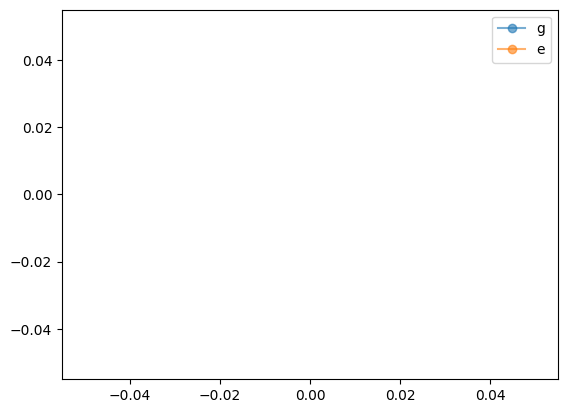

In [666]:
plt.plot(rho_phys_all[:,0,0], label='g', marker='o', alpha=0.6)
plt.plot(rho_phys_all[:,1,1], label='e', marker='o', alpha=0.6)

plt.legend()

In [544]:
prog = StateTomographyT2(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
delay_times = prog.get_time_param('wait', "t", as_array=True)


In [74]:
import imageio, os
out_dir = "T2_Tomography"
os.makedirs(out_dir, exist_ok=True)
png_paths = []
for idx, times in enumerate(delay_times):
    title = f't={times:.1f} μs, prep={run_cfg.get("prep_state","1")}'
    fig = plot_density_matrix(rho_phys_all[idx], title=title, phase_cmap="coolwarm", show=False)
    png_path = os.path.join(out_dir, f"frame_{idx:03d}.png")
    fig.savefig(png_path, dpi=180, bbox_inches="tight")
    plt.close(fig)
    png_paths.append(png_path)

# === 3) 合成 GIF（duration=每張停留秒數；越大越慢）===
images = [imageio.imread(p) for p in png_paths]
imageio.mimsave("T2R.gif", images, fps=3, loop=0) # loop=0 無限循環
print("Saved to T2R.gif")

C:\Users\QEL\AppData\Local\Temp\ipykernel_63372\3880770958.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  facecolors = cm.get_cmap(phase_cmap)(phs_norm.flatten())
C:\Users\QEL\AppData\Local\Temp\ipykernel_63372\4290664961.py:14: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images = [imageio.imread(p) for p in png_paths]


Saved to T2R.gif


# Pi/2 pingpong

In [25]:
class Pingpong(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        
        
        self.add_gauss(ch=res_ch, name="res_ramp",sigma=cfg['res_sigma'], length=5*cfg['res_sigma'], even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="res_ramp",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse1",
                        style="arb",
                        envelope="ramp",
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'],
                        gain=cfg['pi2_gain'],
                        )
            self.add_pulse(ch=qubit_ch, name="qubit_pulse",
                        style="arb",
                        envelope="ramp",
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'],
                        gain=cfg['pi_gain'],
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse1",
                        style="flat_top",
                        envelope="ramp", 
                        length = cfg['flat_top_len'],
                        freq=cfg['f_ge'],
                        phase= cfg['qubit_phase'],
                        gain=cfg['pi2_gain'],
                        )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse1", t=0)
        self.delay_auto(0.01)
        for i in range(cfg['iter']):
            if i ==0:
                continue
            else:
                self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse1", t=0)
                self.delay_auto(0.01)
                self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse1", t=0)
                self.delay_auto(0.01)
            
        self.delay_auto(0.05) 
        
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) 
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [26]:


expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'ramsey_freq':0,
    'iter':1
    }

run_cfg = {**config, **expt_cfg}


In [28]:
from tqdm.notebook import tqdm
pyavg = 30
iteration = np.arange(1, 8, 1)
gainerr = np.arange(-0.02, 0.02, 0.002)
z =[]
for g in tqdm(gainerr, desc='gain err'):
    run_cfg['pi2_gain'] = config['pi2_gain'] + g
    iterlst=[]
    for i in tqdm(iteration, leave=False, desc='iteration'):
        run_cfg['iter']=i
        pp=Pingpong(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = pp.acquire(soc, rounds=pyavg, progress=False, threshold=run_cfg['thresholds'])
        iterlst.append(iq_list[0][0].dot([1,1j]))
    z.append(iterlst)


gain err:   0%|          | 0/20 [00:00<?, ?it/s]

iteration:   0%|          | 0/7 [00:00<?, ?it/s]

iteration:   0%|          | 0/7 [00:00<?, ?it/s]

iteration:   0%|          | 0/7 [00:00<?, ?it/s]

iteration:   0%|          | 0/7 [00:00<?, ?it/s]

...

iteration:   0%|          | 0/7 [00:00<?, ?it/s]

iteration:   0%|          | 0/7 [00:00<?, ?it/s]

iteration:   0%|          | 0/7 [00:00<?, ?it/s]

iteration:   0%|          | 0/7 [00:00<?, ?it/s]

iteration:   0%|          | 0/7 [00:00<?, ?it/s]

9 0.03348194586032573 -0.0020000000000000157


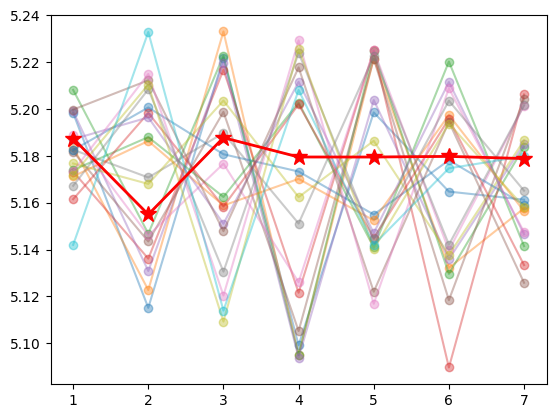

In [29]:
from data_fitting import fitting as fitter
error = []
for i in range(len(gainerr)):
    plt.plot(iteration, np.abs(z)[i], label=f'gain err={gainerr[i]:.3f}', alpha=0.4, marker='o')
    popt, _ = fitter.fit_probg_Xhalf(iteration, np.abs(z)[i])
    error.append(popt[1])

print(np.argmin(np.abs(error)), error[np.argmin(np.abs(error))], gainerr[np.argmin(np.abs(error))])
idx = np.argmin(np.abs(error))
plt.plot(iteration, np.abs(z)[idx], label=f'gain err={gainerr[idx]:.3f}', marker='*', lw=2, alpha=1, color='r',markersize=12,)
# run_cfg['pi2_gain'] = config['pi2_gain'] + gainerr[np.argmin(np.abs(error))]

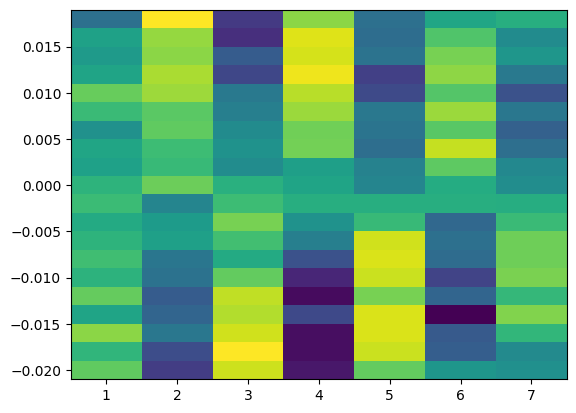

In [30]:
plt.pcolormesh(iteration, gainerr, np.abs(z), shading='auto'    )

In [31]:
run_cfg['pi2_gain'] = config['pi2_gain'] + round(gainerr[np.argmin(np.abs(error))],6)

In [32]:
config['pi2_gain'] += round(gainerr[np.argmin(np.abs(error))],6)

In [33]:
data_path = data_path
exp_name = f"Q{qubit_idx+1} pi2 pulse ping pong"

file_path = get_next_filename_labber(data_path, exp_name, Yoko_current)

hdf5_generator(
        filepath=file_path,
        y_info={'name': 'Dac Gain', 'unit': "a.u",
                'values': gainerr + config['pi2_gain']},  
        x_info={'name': 'Iteration', 'unit': "#",
                'values': iteration},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values': np.array(z)},
        comment=f'',
        tag='PingPong'
)

# Pi pingpong

In [34]:
class Pingpong2(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        
        
        self.add_gauss(ch=res_ch, name="res_ramp",sigma=cfg['res_sigma'], length=5*cfg['res_sigma'], even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="flat_top",
                       envelope="res_ramp",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="pi2_pulse",
                        style="arb",
                        envelope="ramp",
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'],
                        gain=cfg['pi2_gain'],
                        )
            self.add_pulse(ch=qubit_ch, name="pi_pulse",
                        style="arb",
                        envelope="ramp",
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'],
                        gain=cfg['pi_gain'],
                        )

        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse1",
                        style="flat_top",
                        envelope="ramp", 
                        length = cfg['flat_top_len'],
                        freq=cfg['f_ge'],
                        phase= cfg['qubit_phase'],
                        gain=cfg['pi2_gain'],
                        )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=self.cfg["qubit_ch"], name="pi2_pulse", t=0)
        self.delay_auto(0.01)

        for i in range(cfg['iter']):  # iter=1 執行一次，iter=2 執行兩次，以此類推
            if i == 0:
                continue
            else:
                self.pulse(ch=self.cfg["qubit_ch"], name="pi_pulse", t=0)
                self.delay_auto(0.01)
                # self.pulse(ch=self.cfg["qubit_ch"], name="pi_pulse", t=0)
                # self.delay_auto(0.01)


        self.delay_auto(0.05)

        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [35]:


expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'ro_len':5,
    'iter':1
    }

run_cfg = {**config, **expt_cfg}


In [39]:

pyavg = 30
iteration = np.arange(1, 10, 1)
gainerr = np.arange(-0.01, 0.01, 0.001)
z =[]
for g in tqdm(gainerr, desc='gain err'):
    run_cfg['pi_gain'] = config['pi_gain'] + g
    iterlst=[]
    for i in tqdm(iteration, leave=False, desc='iteration'):
        run_cfg['iter']=i
        pp=Pingpong2(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = pp.acquire(soc, rounds=pyavg, progress=False, threshold=run_cfg['thresholds'])
        iterlst.append(iq_list[0][0].dot([1,1j]))
    z.append(iterlst)


gain err:   0%|          | 0/20 [00:00<?, ?it/s]

iteration:   0%|          | 0/9 [00:00<?, ?it/s]

iteration:   0%|          | 0/9 [00:00<?, ?it/s]

iteration:   0%|          | 0/9 [00:00<?, ?it/s]

iteration:   0%|          | 0/9 [00:00<?, ?it/s]

...

iteration:   0%|          | 0/9 [00:00<?, ?it/s]

iteration:   0%|          | 0/9 [00:00<?, ?it/s]

iteration:   0%|          | 0/9 [00:00<?, ?it/s]

iteration:   0%|          | 0/9 [00:00<?, ?it/s]

iteration:   0%|          | 0/9 [00:00<?, ?it/s]

-0.006628949097915971 0.0009999999999999905


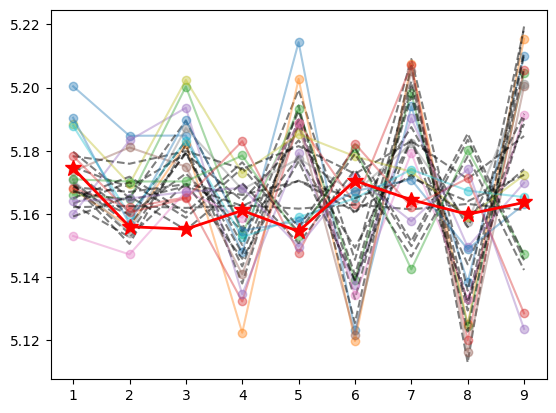

In [41]:
error = []
for i in range(len(gainerr)-5):
    plt.plot(iteration, np.abs(z)[i], label=f'gain err={gainerr[i]:.3f}', marker='o', alpha=0.4)
    
    # popt, _ = fitter.fit_probg_X(iteration, np.abs(z)[i])
    popt, _ = fitter.fit_probg_Xhalf(iteration, np.abs(z)[i])
    # plt.plot(iteration, fitter.probg_X(iteration, *popt), linestyle='--', color='k', alpha=0.5)
    plt.plot(iteration, fitter.probg_Xhalf(iteration, *popt), linestyle='--', color='k', alpha=0.5)
    error.append(popt[1])

print(error[np.argmin(np.abs(error))], gainerr[np.argmin(np.abs(error))])
idx = np.argmin(np.abs(error))
plt.plot(iteration, np.abs(z)[idx], label=f'gain err={gainerr[idx]:.3f}', marker='*', lw=2, alpha=1, color='r',markersize=12,)
run_cfg['pi_gain'] = config['pi_gain'] + gainerr[idx]

In [42]:
config['pi_gain'] += round(gainerr[np.argmin(np.abs(error))],6)

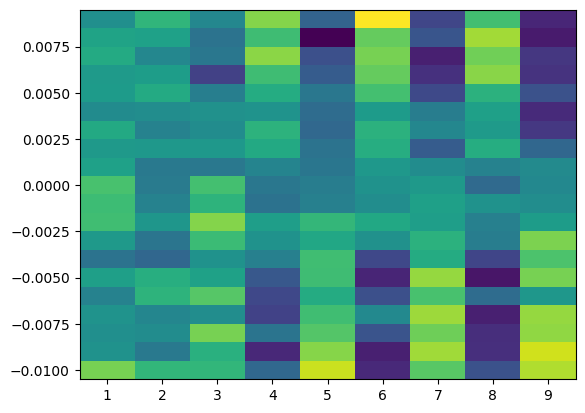

In [43]:
plt.pcolormesh(iteration, gainerr, np.abs(z), shading='auto')